# Test of the cluster simulation code

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
from astropy import units as u
# from astroquery.gaia import Gaia
from ocelot.simulate import (
    SimulatedCluster,
    SimulatedClusterParameters,
    SimulatedClusterModels,
)
from gaianir_open_clusters.cluster_model import GaiaNIRObservationModel
# from ocelot.model.observation import (
#     GaiaDR3ObservationModel,
#     GenericSubsampleSelectionFunction,
# )
from sklearn.neighbors import NearestNeighbors

## Simulating a cluster!

In [16]:
position = SkyCoord(
    l=180 * u.deg,
    b=0 * u.deg,
    distance=10000 * u.pc,
    pm_l_cosb=10 * u.mas / u.yr,
    pm_b=0 * u.mas / u.yr,
    radial_velocity=0 * u.km / u.s,
    frame="galactic",
)

parameters = SimulatedClusterParameters(
    position=position,
    mass=1000,
    log_age=9,
    metallicity=-2.5,
    extinction=5.0,
    r_core=2,
    r_tidal=10,
    virial_ratio=0.5
)

In [17]:
# Gaia.ROW_LIMIT = 10000
# query = Gaia.cone_search(parameters.position, radius=0.5 * u.deg)
# gaia_data = query.get_results().to_pandas().rename(columns={"SOURCE_ID": "source_id"})

In [18]:
models = SimulatedClusterModels(
    observations=[
        GaiaNIRObservationModel(
            mission_class="GaiaNIR-L", years=10, maximum_magnitude=22
        ),
        # GaiaNIRObservationModel(
        #     mission_class="Gaia",
        #     years=10,
        #     maximum_magnitude=19,
        #     combined_astrometry=False,
        # ),
        # GaiaDR3ObservationModel(
        #     representative_stars=gaia_data, overestimate_bp_rp_fluxes=False
        # ),
    ]
)

In [19]:
cluster = SimulatedCluster(random_seed=42, parameters=parameters, models=models)
cluster.make()

/home/emily/code/gaianir-open-clusters/.venv/lib/python3.13/site-packages/ocelot/simulate/photometry.py:43: UserWarning: Desired metallicity of [M/H]=-2.50000 is less than the minimum available of {MINIMUM_METALLICITY}!
  warnings.warn(


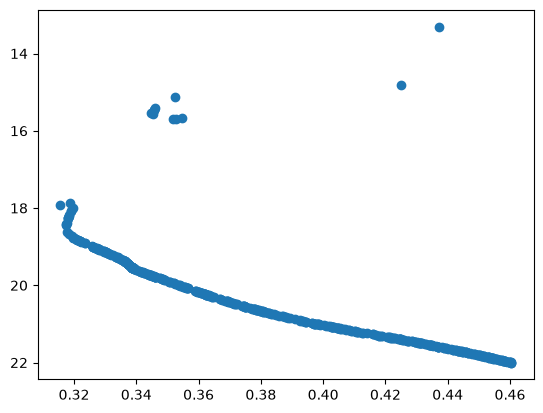

In [20]:
obs = cluster.observations['gaianir-l-10-(combined)']
plt.scatter(obs['gaianir_h'] - obs['gaianir_k'], obs['gaianir_n'])
plt.gca().invert_yaxis()

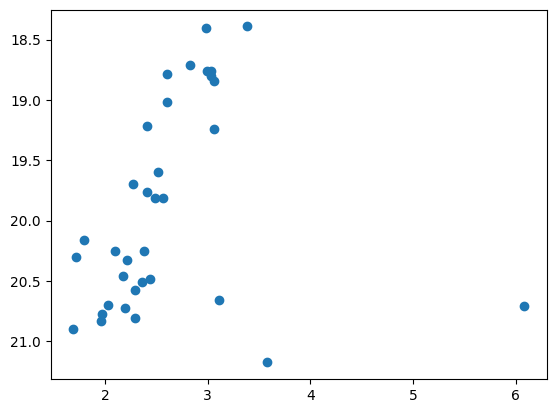

In [ ]:
obs = cluster.observations['gaia_dr3']
plt.scatter(obs['gaia_dr3_bp'] - obs['gaia_dr3_rp'], obs['gaia_dr3_g'])
plt.gca().invert_yaxis()

In [62]:
cluster.observations['gaia_dr3'].columns

Index(['simulated_id', 'cluster_id', 'simulated_star', 'mass_initial', 'mass',
       'temperature', 'luminosity', 'log_g', 'gaia_dr3_g_true',
       'gaia_dr3_bp_true', 'gaia_dr3_rp_true', 'companions', 'mass_ratio',
       'period', 'eccentricity', 'simulated_id_primary', 'ra', 'dec', 'l', 'b',
       'pmra', 'pmdec', 'parallax', 'pmra_true', 'pmdec_true', 'parallax_true',
       'radial_velocity_true', 'extinction', 'extinction_gaia_dr3_g',
       'extinction_gaia_dr3_bp', 'extinction_gaia_dr3_rp', 'gaia_dr3_g',
       'gaia_dr3_bp', 'gaia_dr3_rp', 'unresolved_companions',
       'matching_gaia_dr3_source_id', 'gaia_dr3_g_flux_error',
       'gaia_dr3_bp_flux_error', 'gaia_dr3_rp_flux_error', 'pmra_error',
       'pmdec_error', 'parallax_error',
       'selection_probability_GaiaDR3SelectionFunction',
       'selection_probability'],
      dtype='object')

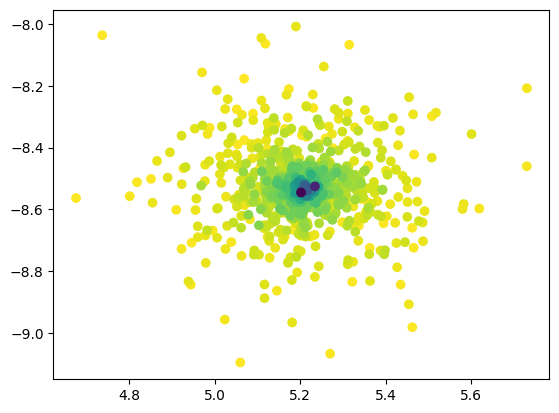

In [63]:
obs = cluster.observations['gaianir-l-10-(combined)']
obs = obs.sort_values("gaianir_n", ascending=False)
plt.scatter(obs['pmra'], obs['pmdec'], c=obs['gaianir_n'])

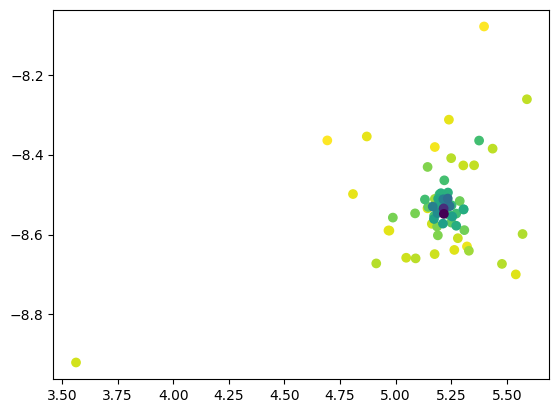

In [64]:
obs = cluster.observations['gaia_dr3']
obs = obs.sort_values("gaia_dr3_g", ascending=False)
plt.scatter(obs['pmra'], obs['pmdec'], c=obs['gaia_dr3_g'])

In [65]:
cluster.observations.keys()

dict_keys(['gaianir-l-10-(combined)', 'gaia_dr3'])

In [66]:
cluster.observations['gaia_dr3']['luminosity']

0          1.152115
1          1.639087
2          1.786609
3          1.956532
4          2.043261
          ...      
64      5091.168913
65      9899.445951
66     11342.349027
67    131923.058275
68    526136.536631
Name: luminosity, Length: 69, dtype: float64

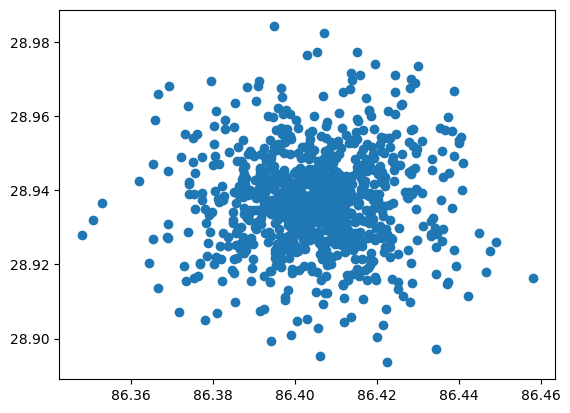

In [67]:
obs = cluster.observations['gaianir-l-10-(combined)']

plt.scatter(obs['ra'], obs['dec'])

In [86]:
obs = cluster.observations['gaianir-l-10-(combined)']
neighbors = NearestNeighbors(radius=0.2 / 60**2 * np.pi / 180, metric="haversine")
neighbors.fit(obs[['ra', 'dec']] * np.pi / 180)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",9.69627362219072e-07
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'haversine'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [ ]:
distances, indices = neighbors.radius_neighbors(obs[['ra', 'dec']] * np.pi / 180)

(array([309.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,  12.]),
 array([1. , 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. ]),
 <BarContainer object of 10 artists>)

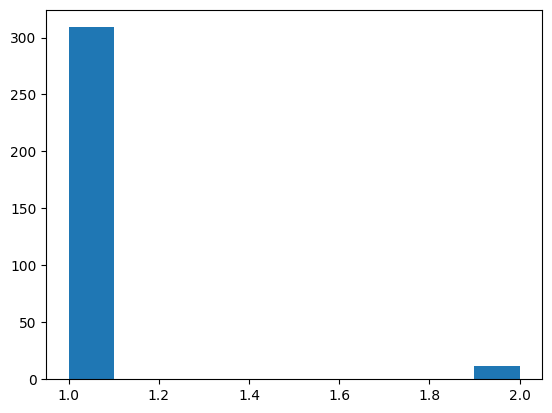

In [88]:
plt.hist([len(x) for x in indices])